# Deep Learning with Larger Tabular Data

Building on Iris (150 samples, 4 features, 3 classes), today we tackle:
- **Regression** - predicting a number (California Housing: 20k samples)
- **Binary Classification** - predicting yes/no (Adult Income: 48k samples)
- **Regularization** - Dropout and Early Stopping

---
# PART 1: REGRESSION - California Housing
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping  # we'll use this later to stop training early
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.1


In [2]:
housing = fetch_california_housing()  # 20k samples, 8 features, predict house price
X, y = housing.data, housing.target

print(f"Shape: {X.shape} - compare to Iris's 150 samples!")
print(f"Features: {housing.feature_names}")

Shape: (20640, 8) - compare to Iris's 150 samples!
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [3]:
df = pd.DataFrame(X, columns=housing.feature_names)
df['MedHouseVal'] = y  # target is in $100,000s (so 2.5 = $250,000)
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


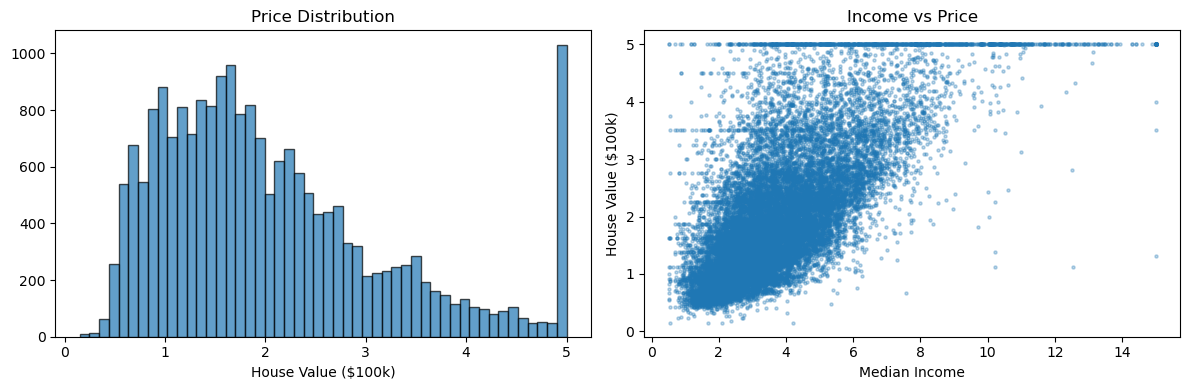

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('House Value ($100k)'); axes[0].set_title('Price Distribution')
axes[1].scatter(df['MedInc'], y, alpha=0.3, s=5)  # MedInc is the strongest predictor
axes[1].set_xlabel('Median Income'); axes[1].set_ylabel('House Value ($100k)'); axes[1].set_title('Income vs Price')
plt.tight_layout(); plt.show()

In [5]:
# Split: 60% train, 20% val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit only on train!
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

Train: 12,384 | Val: 4,128 | Test: 4,128


In [6]:
# Build regression model
# KEY DIFFERENCES from classification:
#   - Output: 1 neuron, NO activation (linear output)
#   - Loss: 'mse' (mean squared error)
#   - Metric: 'mae' (mean absolute error - interpretable as "off by $X")

regression_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(8,)),  # 8 features
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # NO activation for regression!
])

# Why MSE for loss vs MAE for metrics?
# - LOSS (what the model learns from): MSE penalizes big errors MORE than small ones
#   (squaring makes 10 become 100, but 2 only becomes 4). This pushes the model
#   to avoid large mistakes during training.
# - METRIC (what WE look at): MAE is easier to interpret - "on average, we're off by $X"
#   We don't use MAE as loss because its gradient is constant (harder to optimize).
regression_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
regression_model.summary()

/Users/davidfekke/Documents/python/projects/mynotebooks/unit-4-lessons/.pixi/envs/default/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-11 22:33:42.780437: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-02-11 22:33:42.780484: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-02-11 22:33:42.780495: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-02-11 22:33:42.780671: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-11 22:33:42.780691: I tensorflow/core/common_r

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Why do we save model.fit() to a variable called "history"?
# model.fit() returns a History object that records loss and metrics at EVERY epoch.
# We save it so we can plot training progress over time (see next cell).
# Without saving it, we'd lose this information after training finishes!

history = regression_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

Epoch 1/100


2026-02-11 22:33:49.248894: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.4877 - mae: 0.8239 - val_loss: 1.4260 - val_mae: 0.5852
Epoch 2/100
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.6138 - mae: 0.5392 - val_loss: 0.6688 - val_mae: 0.5536
Epoch 3/100
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6677 - mae: 0.5306 - val_loss: 6.6401 - val_mae: 0.5738
Epoch 4/100
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1.0284 - mae: 0.5439 - val_loss: 3.8486 - val_mae: 0.5611
Epoch 5/100
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.8645 - mae: 0.5630 - val_loss: 0.6523 - val_mae: 0.5433
Epoch 6/100
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.5831 - mae: 0.5566 - val_loss: 6.7441 - val_mae: 0.5724
Epoch 7/100
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.1625 - mae: 0.5818 - val_loss: 22.8784 - val_mae: 0.6132
Epoch 8/100
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.8761 - mae: 0.5719 - val_loss: 4.8648 - val_mae: 0.5831
Epoch 9/100
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss

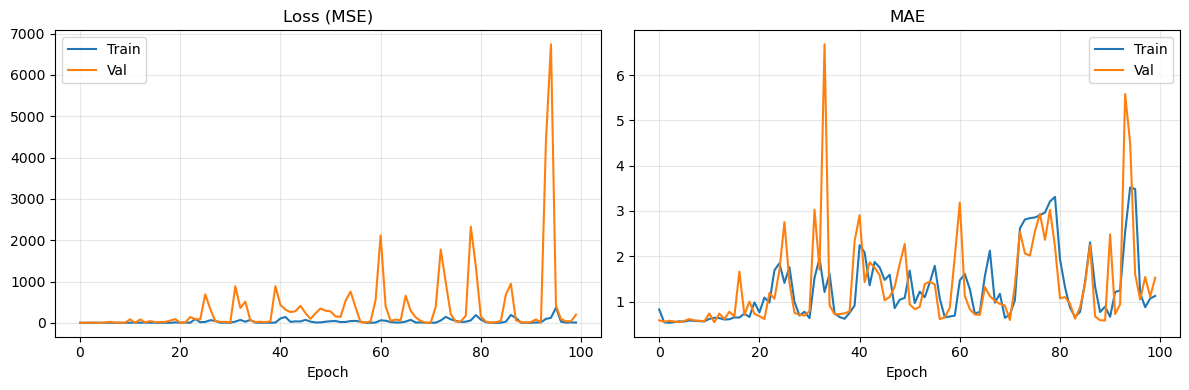

In [8]:
# history.history is a dictionary with keys like 'loss', 'mae', 'val_loss', 'val_mae'
# Each key maps to a list of values (one per epoch) so we can see how training evolved
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train')      # training loss each epoch
axes[0].plot(history.history['val_loss'], label='Val')    # validation loss each epoch
axes[0].set_title('Loss (MSE)'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['mae'], label='Train')       # training MAE each epoch
axes[1].plot(history.history['val_mae'], label='Val')     # validation MAE each epoch
axes[1].set_title('MAE'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [9]:
test_mse, test_mae = regression_model.evaluate(X_test_scaled, y_test)  # evaluate on held-out test set
print(f"\n💡 On average, predictions are off by ${test_mae * 100000:,.0f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.6970 - mae: 1.2683

💡 On average, predictions are off by $126,833


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


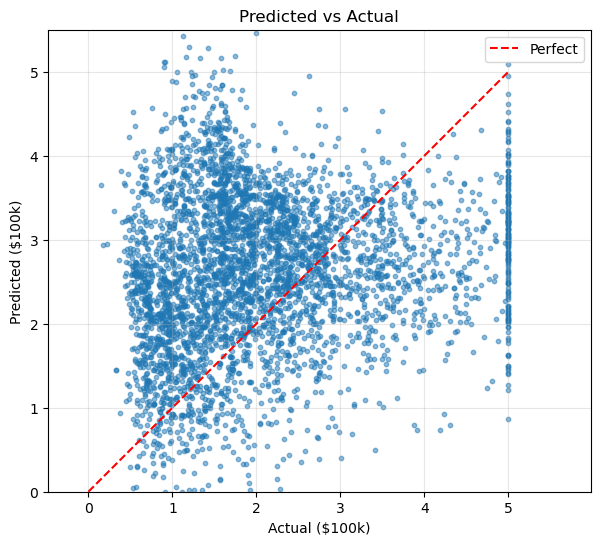

In [10]:
y_pred = regression_model.predict(X_test_scaled).flatten()  # get predictions for test set

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=10)
plt.plot([0, 5], [0, 5], 'r--', label='Perfect')  # diagonal line = perfect predictions
plt.xlabel('Actual ($100k)'); plt.ylabel('Predicted ($100k)')
plt.title('Predicted vs Actual'); plt.legend(); plt.grid(True, alpha=0.3)
plt.axis('equal'); plt.xlim(0, 5.5); plt.ylim(0, 5.5); plt.show()

In [11]:
improved_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(8,)),
    layers.Dropout(0.2),  # Dropout: randomly drops 20% of neurons to prevent overfitting
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])
improved_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stopping = EarlyStopping(
    monitor='val_loss',        # watch validation loss
    patience=10,               # stop if no improvement for 10 epochs
    restore_best_weights=True  # keep the best model, not the last one
)

history_improved = improved_model.fit(
    X_train_scaled, y_train,
    epochs=200,                          # set high - early stopping will stop us when we stop improving
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping],          # pass callbacks as a list
    verbose=1
)
print(f"\nStopped at epoch {len(history_improved.history['loss'])}")

Epoch 1/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 2.1345 - mae: 0.9914 - val_loss: 4.4036 - val_mae: 0.5651
Epoch 2/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.7548 - mae: 0.7474 - val_loss: 3.1142 - val_mae: 0.5510
Epoch 3/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.4578 - mae: 0.6913 - val_loss: 2.2676 - val_mae: 0.5465
Epoch 4/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.5865 - mae: 0.6830 - val_loss: 2.7104 - val_mae: 0.5549
Epoch 5/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.8226 - mae: 0.6980 - val_loss: 0.9438 - val_mae: 0.5460
Epoch 6/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2.2545 - mae: 0.7221 - val_loss: 17.0416 - val_mae: 0.5813
Epoch 7/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2.4120 - mae: 0.7483 - val_loss: 9.8120 - val_mae: 0.5938
Epoch 8/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2.6020 - mae: 0.8341 - val_loss: 0.5598 - val_mae: 0.5636
Epoch 9/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms

In [12]:
test_mse_imp, test_mae_imp = improved_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Basic Model MAE:    ${test_mae * 100000:,.0f}")
print(f"Improved Model MAE: ${test_mae_imp * 100000:,.0f}")

Basic Model MAE:    $126,833
Improved Model MAE: $56,116


---
# PART 2: BINARY CLASSIFICATION - Adult Income
---

In [13]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

print("Loading Adult Income dataset...")
adult = fetch_openml(name='adult', version=2, as_frame=True)  # predict if income >$50K (binary: yes/no)
print(f"Shape: {adult.data.shape} - much bigger than Iris!")

Loading Adult Income dataset...
Shape: (48842, 14) - much bigger than Iris!


In [14]:
df_adult = adult.data.copy()
df_adult['income'] = adult.target
df_adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [15]:
print("Class distribution:")
print(df_adult['income'].value_counts())  # check if classes are balanced

Class distribution:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


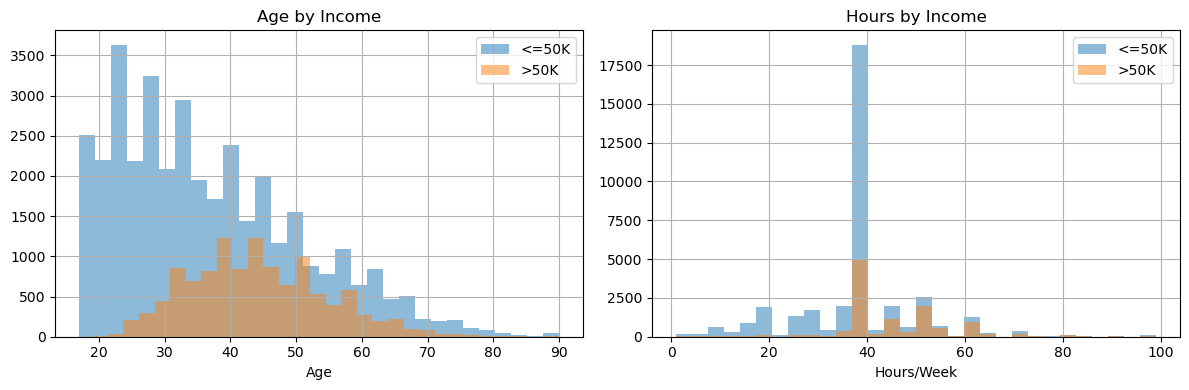

In [16]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_adult[df_adult['income'] == '<=50K']['age'].hist(ax=axes[0], alpha=0.5, label='<=50K', bins=30)
df_adult[df_adult['income'] == '>50K']['age'].hist(ax=axes[0], alpha=0.5, label='>50K', bins=30)
axes[0].set_xlabel('Age'); axes[0].set_title('Age by Income'); axes[0].legend()
df_adult[df_adult['income'] == '<=50K']['hours-per-week'].hist(ax=axes[1], alpha=0.5, label='<=50K', bins=30)
df_adult[df_adult['income'] == '>50K']['hours-per-week'].hist(ax=axes[1], alpha=0.5, label='>50K', bins=30)
axes[1].set_xlabel('Hours/Week'); axes[1].set_title('Hours by Income'); axes[1].legend()
plt.tight_layout(); plt.show()

In [17]:
X_adult = adult.data
y_adult = (adult.target == '>50K').astype(int)  # convert '>50K'/'>50K' to 1, '<=50K' to 0

numeric_features = X_adult.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_adult.select_dtypes(include=['category', 'object']).columns.tolist()
print(f"Numeric: {numeric_features}")
print(f"Categorical: {categorical_features}")  # these need to be one-hot encoded

Numeric: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [18]:
# Why ColumnTransformer?
# Our data has TWO types of features that need DIFFERENT preprocessing:
#   - Numeric (age, hours-per-week): need StandardScaler (mean=0, std=1)
#   - Categorical (workclass, education): need OneHotEncoder (text → 0/1 columns)
# ColumnTransformer lets us apply different transformations to different columns
# in ONE step, keeping everything organized.

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),                                      # scale numeric features
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)  # one-hot encode categorical
])

X_temp, X_test_a, y_temp, y_test_a = train_test_split(X_adult, y_adult, test_size=0.2, random_state=42, stratify=y_adult)
X_train_a, X_val_a, y_train_a, y_val_a = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# fit_transform vs transform - THIS IS CRITICAL!
# - fit_transform(X_train): LEARNS the parameters from training data (mean, std, categories)
#   AND applies the transformation. Only do this on TRAINING data!
# - transform(X_val, X_test): APPLIES the same learned parameters without re-learning.
#   This ensures val/test are scaled the same way as training data.
# If we fit on test data, we'd be "peeking" at test info → data leakage!

X_train_proc = preprocessor.fit_transform(X_train_a)  # fit on train only!
X_val_proc = preprocessor.transform(X_val_a)
X_test_proc = preprocessor.transform(X_test_a)
y_train_a, y_val_a, y_test_a = y_train_a.values, y_val_a.values, y_test_a.values

print(f"Train: {len(X_train_a):,} | Val: {len(X_val_a):,} | Test: {len(X_test_a):,}")
print(f"Features after one-hot encoding: {X_train_proc.shape[1]}")  # categorical features expand into many columns

Train: 29,304 | Val: 9,769 | Test: 9,769
Features after one-hot encoding: 108


In [19]:
n_features = X_train_proc.shape[1]

binary_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(n_features,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # SIGMOID outputs probability 0-1, >0.5 = class 1
])

binary_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # use binary_crossentropy for 2-class problems
    metrics=['accuracy']
)
binary_model.summary()

/Users/davidfekke/Documents/python/projects/mynotebooks/unit-4-lessons/.pixi/envs/default/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         6,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# model.fit() returns a History object - same as before, records metrics at each epoch
history_bin = binary_model.fit(
    X_train_proc, y_train_a,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_proc, y_val_a),
    verbose=1
)

Epoch 1/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8418 - loss: 0.3370 - val_accuracy: 0.8527 - val_loss: 0.3168
Epoch 2/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8482 - loss: 0.3228 - val_accuracy: 0.8512 - val_loss: 0.3193
Epoch 3/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8485 - loss: 0.3225 - val_accuracy: 0.8518 - val_loss: 0.3172
Epoch 4/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8488 - loss: 0.3234 - val_accuracy: 0.8495 - val_loss: 0.3262
Epoch 5/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8489 - loss: 0.3241 - val_accuracy: 0.8548 - val_loss: 0.3171
Epoch 6/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8483 - loss: 0.3245 - val_accuracy: 0.8497 - val_loss: 0.3233
Epoch 7/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8472 - loss: 0.3269 - val_accuracy: 0.8441 - val_loss: 0.3401
Epoch 8/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8458 - loss: 0.3322 - val_accu

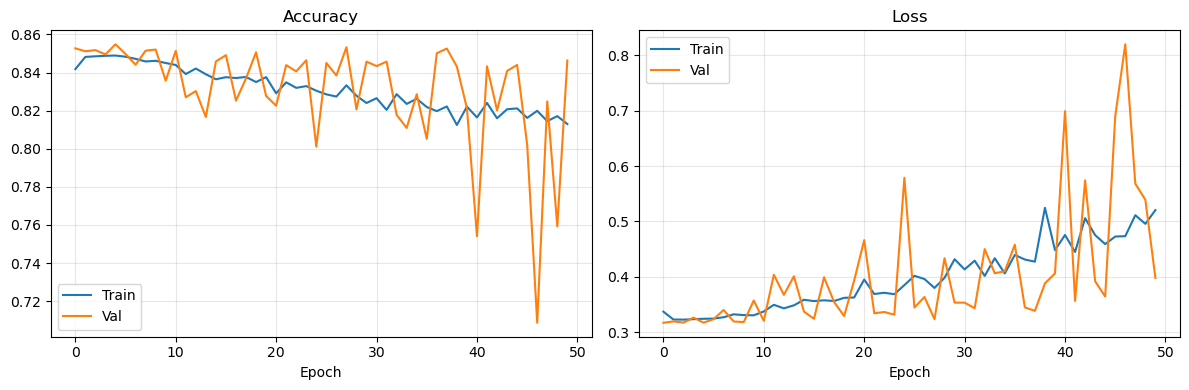

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_bin.history['accuracy'], label='Train')      # history.history has 'accuracy' for classification
axes[0].plot(history_bin.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history_bin.history['loss'], label='Train')
axes[1].plot(history_bin.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [22]:
test_loss, test_acc = binary_model.evaluate(X_test_proc, y_test_a)
print(f"\n🎯 Test Accuracy: {test_acc*100:.1f}%")

306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8442 - loss: 0.4080

🎯 Test Accuracy: 84.4%


306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


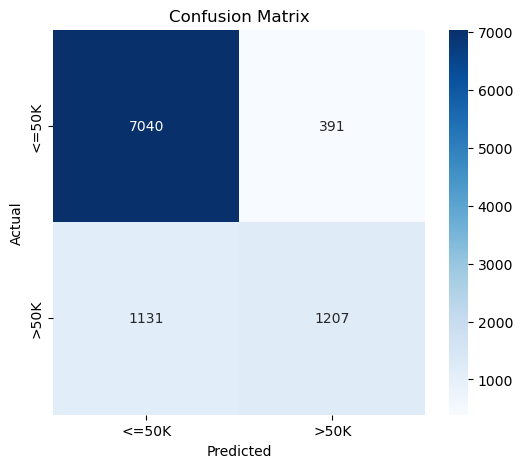

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_proba = binary_model.predict(X_test_proc)              # get probabilities (0-1)
y_pred_bin = (y_pred_proba > 0.5).astype(int).flatten()       # convert to 0/1 predictions

cm = confusion_matrix(y_test_a, y_pred_bin)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix'); plt.show()

In [25]:
print(classification_report(y_test_a, y_pred_bin, target_names=['<=50K', '>50K']))

              precision    recall  f1-score   support

       <=50K       0.86      0.95      0.90      7431
        >50K       0.76      0.52      0.61      2338

    accuracy                           0.84      9769
   macro avg       0.81      0.73      0.76      9769
weighted avg       0.84      0.84      0.83      9769



In [26]:
improved_bin = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(n_features,)),
    layers.Dropout(0.3),  # higher dropout for larger network
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
improved_bin.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop_bin = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_imp_bin = improved_bin.fit(
    X_train_proc, y_train_a,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_proc, y_val_a),
    callbacks=[early_stop_bin],
    verbose=1
)
print(f"\nStopped at epoch {len(history_imp_bin.history['loss'])}")

Epoch 1/100


/Users/davidfekke/Documents/python/projects/mynotebooks/unit-4-lessons/.pixi/envs/default/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


458/458 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8184 - loss: 0.3950 - val_accuracy: 0.8470 - val_loss: 0.3246
Epoch 2/100
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8151 - loss: 0.4319 - val_accuracy: 0.8427 - val_loss: 0.3287
Epoch 3/100
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8339 - loss: 0.3578 - val_accuracy: 0.8479 - val_loss: 0.3230
Epoch 4/100
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8382 - loss: 0.3469 - val_accuracy: 0.8472 - val_loss: 0.3247
Epoch 5/100
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8368 - loss: 0.3499 - val_accuracy: 0.8489 - val_loss: 0.3199
Epoch 6/100
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8380 - loss: 0.3515 - val_accuracy: 0.8494 - val_loss: 0.3220
Epoch 7/100
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8364 - loss: 0.3530 - val_accuracy: 0.8423 - val_loss: 0.3403
Epoch 8/100
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8355 - loss: 0.3585 - val_accuracy

In [27]:
_, acc_imp = improved_bin.evaluate(X_test_proc, y_test_a, verbose=0)
print(f"Basic Model:    {test_acc*100:.2f}%")
print(f"Improved Model: {acc_imp*100:.2f}%")

Basic Model:    84.42%
Improved Model: 85.29%
